# Conjuction finder

In [1]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pathlib

import geospacelab.visualization.mpl.dashboards as dashboards

Create a new figure: Figure(800x1000).
Searching the data product "FAC_TMS" with the version "latest" on the server...
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/FAC_TMS/0401/Sat_A/2024/SW_OPER_FACATMS_2F_20240510T000000_20240510T235959_0401.cdf')] already exists: skip downloading.
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/FAC_TMS/0401/Sat_A/2024/SW_OPER_FACATMS_2F_20240511T000000_20240511T235959_0401.cdf')] already exists: skip downloading.
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/FAC_TMS/0401/Sat_A/2024/SW_OPER_FACATMS_2F_20240512T000000_20240512T235959_0401.cdf')] already exists: skip downloading.
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/FAC_TMS/0401/Sat_A/2024/SW_OPER_FACATMS_2F_20240513T000000_20240513T235959_0401.cdf')] already exists: skip downloading.
4 conjunction(s) found:
Index  Time (Start)         EL (Start) AZ (Start) D (Start)  Time (Highest)            EL (Hi

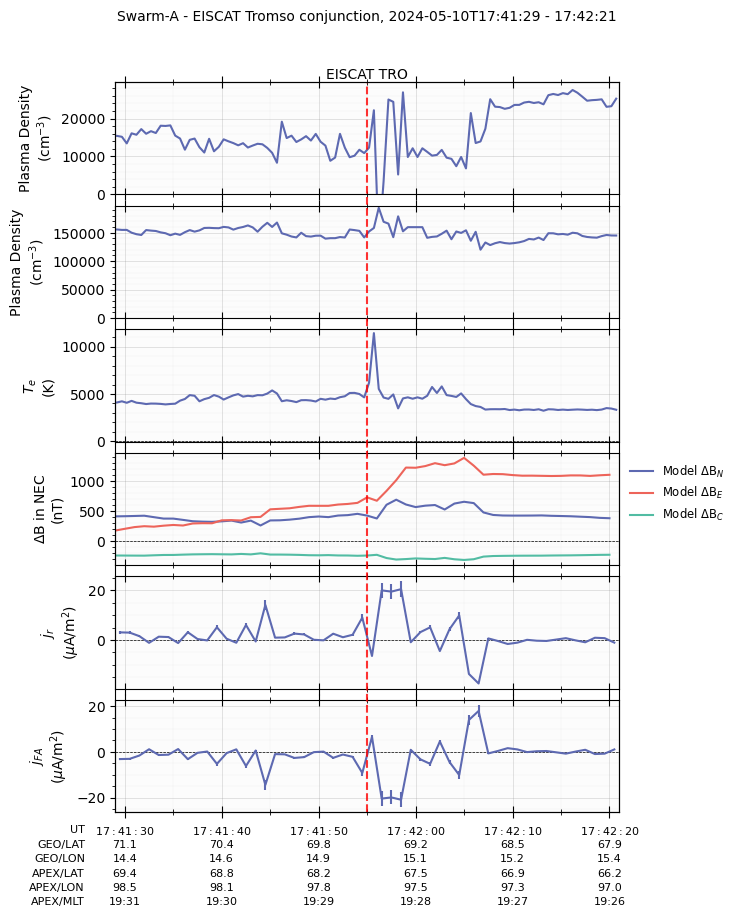

In [5]:
def test_conjunction_with_site():
    """Test Swarm EFI/LP 1B data product
    
    """
    dt_fr = datetime.datetime(2024, 5, 10, 0, )
    dt_to = datetime.datetime(2024, 5, 13, 0, 0)

    site_info = {
        'glat': 69.58, 'glon': 19.23, 'alt': 0. # EISCAT Tromso site
    }
    
    db = dashboards.TSDashboard(
        dt_fr=dt_fr, dt_to=dt_to, figure_config={'figsize': (8, 10)},
        timeline_extra_labels=['GEO_LAT', 'GEO_LON', 'APEX_LAT', 'APEX_LON', 'APEX_MLT',]
        )

    ds_fac = db.dock(
        datasource_contents=['esa_eo', 'swarm', 'l2daily', 'fac_tms'], 
        product_version='latest', # 'latest' (default),
        sat_id='A', add_APEX=False)
    
    conj_list = ds_fac.get_conjunction_with_site(
         glat_site=site_info['glat'], glon_site=site_info['glon'], alt_site=site_info['alt'],
         el_lim=60.,
         print_conj_list=True,
     )
    conj_data = conj_list[1]
    dt_fr_to_show = conj_data['DATETIME_0']
    dt_to_to_show = conj_data['DATETIME_1']
    
    ds_fac.dt_fr = dt_fr_to_show
    ds_fac.dt_to = dt_to_to_show
    ds_fac.time_filter_by_range()
    ds_fac.convert_to_APEX()
    
    ds_efi_lp = db.dock(
        dt_fr=dt_fr_to_show, dt_to=dt_to_to_show,
        datasource_contents=['esa_eo', 'swarm', 'l1b', 'efi_lp'], 
        product_version='latest', # 'latest' (default),
        sat_id='A', add_APEX=True)
    
    ds_mag_lr = db.dock(
        dt_fr=dt_fr_to_show, dt_to=dt_to_to_show,
        datasource_contents=['esa_eo', 'swarm', 'l1b', 'mag_lr'], 
        from_HAPI=True,
        product_version='latest', # 'latest' (default),
        sat_id='A', add_APEX=True)
    
    panel_layouts = [
        [ds_efi_lp['n_e']],
        [ds_efi_lp['n_i']],
        [ds_efi_lp['T_e']],
        [ds_mag_lr['B_res_Model_N'], ds_mag_lr['B_res_Model_E'], ds_mag_lr['B_res_Model_C']],
        [ds_fac['j_r']],
        [ds_fac['j_FA']],
    ]

    db.set_layout(panel_layouts=panel_layouts)
    db.draw(
        dt_fr=dt_fr_to_show, dt_to=dt_to_to_show,
    )
    
    # Add a vertical line to indicate the conjunction time
    db.add_vertical_line(
        conj_data['DATETIME'], label='EISCAT TRO', color='red', linestyle='--', linewidth=1.5,
    )
    db.add_title(title='Swarm-{} - EISCAT Tromso conjunction'.format(ds_fac.sat_id), fontsize='medium', append_time=True)

    return db
db = test_conjunction_with_site()
db.show()